In [1]:
include(joinpath(@__DIR__, "..", "readclassjson.jl"))
using JSON
using LinearAlgebra
using Statistics
using Plots

In [8]:
nsteps = 300
data = readclassjson("low_rank_matrix_completion.json")
Atrue = data["Atrue"]
r = data["r"]
Aknown = data["Aknown"]
K = data["K"]
p = data["p"]
n = data["n"]

120

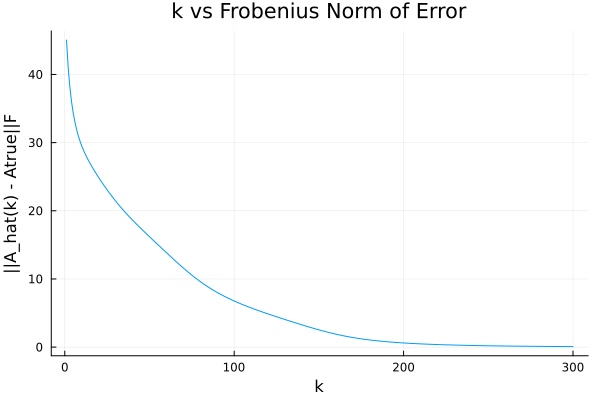

In [6]:
# Initialize A_hat_k0
mu = mean(Aknown)
A_hat_k = fill(mu, size(Atrue))
for idx in 1:size(K, 1)
    i, j = K[idx, 1], K[idx, 2]
    A_hat_k[i,j] = Aknown[idx]
end

frobError = zeros(nsteps)

# Do alternate projections
for k in 1:nsteps
    # step (i)
    U, S, V = svd(A_hat_k)
    Ur = U[:,1:r]
    Sr = diagm(S[1:r])
    Vr = V[:,1:r]

    A_tilda_k = Ur * Sr * Vr'

    # step (ii)
    for idx in 1:size(K, 1)
        i, j = K[idx, 1], K[idx, 2]
        A_tilda_k[i,j] = Aknown[idx]
    end

    A_hat_k = A_tilda_k
    frobError[k] = norm(A_hat_k[:] - Atrue[:])
end

plot_b = plot(1:nsteps, frobError, xlabel="k", ylabel="||A_hat(k) - Atrue||F"
              , legend=false, title="k vs Frobenius Norm of Error")

display(plot_b)